# 🔥 SafeSense-VI: PhoBERT-base-v2 Training
**Vietnamese Toxic Comment Classification**

## Hướng dẫn:
1. Upload file `final_train_data_v3_READY_PHOBERT_SEGMENTED.xlsx` lên Google Drive
2. Thay đổi `DATA_PATH` trong Config
3. Chạy từng cell theo thứ tự

In [18]:
# CELL 1: Install Dependencies
!pip install transformers accelerate openpyxl -q
print('✅ Dependencies installed!')

✅ Dependencies installed!


In [19]:
# CELL 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted!


In [20]:
# CELL 3: Import Libraries
import os, random, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print('✅ Libraries imported!')

✅ Libraries imported!


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2: Configuration
# ═══════════════════════════════════════════════════════════════════════════════

class Config:
    # Model
    MODEL_NAME = "vinai/phobert-base-v2"
    NUM_LABELS = 3
    MAX_LENGTH = 256

    # Training
    BATCH_SIZE = 16
    GRADIENT_ACCUMULATION_STEPS = 2  # Effective batch = 32
    EPOCHS = 7
    LEARNING_RATE = 3e-5
    WEIGHT_DECAY = 0.01
    WARMUP_RATIO = 0.15

    # Optimization
    USE_CLASS_WEIGHTS = True
    LABEL_SMOOTHING = 0.1

    # Early stopping
    PATIENCE = 2

    # Seed
    SEED = 42

    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Google Colab Paths (THAY ĐỔI ĐƯỜNG DẪN NÀY)
    DATA_PATH = "/content/drive/MyDrive/Deep_Learning_hate_speech_V3/final_train_data_v3_READY_PHOBERT_20260102_053035_SEGMENTED_20260102_053456.csv"
    OUTPUT_DIR = "/content/drive/MyDrive/SafeSense-VI/output_v2"
    MODEL_SAVE_PATH = "/content/drive/MyDrive/SafeSense-VI/phobert_toxic_model_v2"


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True


set_seed(Config.SEED)

print('✅ Configuration set!')
print(f'🔧 Device: {Config.DEVICE}')
print(f'🔧 Model: {Config.MODEL_NAME}')
print(f'🔧 Batch Size: {Config.BATCH_SIZE} x {Config.GRADIENT_ACCUMULATION_STEPS} = {Config.BATCH_SIZE * Config.GRADIENT_ACCUMULATION_STEPS}')


✅ Configuration set!
🔧 Device: cuda
🔧 Model: vinai/phobert-base-v2
🔧 Batch Size: 16 x 2 = 32


In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4: Load & Preprocess Data
# ═══════════════════════════════════════════════════════════════════════════════

def load_and_preprocess_data(data_path):
    """Load và preprocess data cho PhoBERT training"""
    print("="*80)
    print("📊 LOADING & PREPROCESSING DATA")
    print("="*80)

    # Load Data
    if data_path.endswith('.xlsx'):
        df = pd.read_excel(data_path)
    else:
        df = pd.read_csv(data_path)

    print(f"📂 Loaded: {len(df):,} samples")
    print(f"📂 Columns: {df.columns.tolist()}")

    # Identify Columns
    text_col = 'training_text' if 'training_text' in df.columns else 'text'
    label_col = 'label'

    # Clean data
    df[label_col] = pd.to_numeric(df[label_col], errors='coerce')
    initial_len = len(df)
    df = df.dropna(subset=[text_col, label_col])
    df[label_col] = df[label_col].astype(int)

    if len(df) < initial_len:
        print(f"⚠️ Removed {initial_len - len(df)} samples with missing values.")

    print(f"\n📂 Final Dataset Size: {len(df):,} samples")
    print(f"📝 Text column: {text_col} | Label column: {label_col}")

    # Check word segmentation
    sample_text = str(df[text_col].iloc[0])
    underscore_count = sample_text.count('_')
    print(f"\n🔍 WORD SEGMENTATION CHECK:")
    print(f"   Sample: {sample_text[:100]}...")
    if underscore_count > 0:
        print(f"   ✅ Data is PRE-SEGMENTED (Underscores: {underscore_count})")
    else:
        print(f"   ⚠️ Data is NOT segmented!")

    # Label distribution
    print(f"\n📊 LABEL DISTRIBUTION:")
    label_counts = df[label_col].value_counts().sort_index()
    label_names = {0: 'Clean', 1: 'Offensive', 2: 'Hate'}

    for label, count in label_counts.items():
        pct = (count / len(df)) * 100
        name = label_names.get(int(label), 'Unknown')
        print(f"   Label {int(label)} ({name}): {count:,} ({pct:.2f}%)")

    return df, text_col, label_col


# Load data
df, text_col, label_col = load_and_preprocess_data(Config.DATA_PATH)



📊 LOADING & PREPROCESSING DATA
📂 Loaded: 6,974 samples
📂 Columns: ['training_text', 'text_raw', 'label', 'note', 'source_file', 'labeler', 'has_teencode', 'confidence', 'sampling_strategy', 'raw_comment', 'raw_title', 'training_text_original']

📂 Final Dataset Size: 6,974 samples
📝 Text column: training_text | Label column: label

🔍 WORD SEGMENTATION CHECK:
   Sample: gì , với sự góp_mặt của tiktoker trà bông trong vai_trò khách mời . cả nhà cùng đón xem nhé ! body s...
   ✅ Data is PRE-SEGMENTED (Underscores: 6)

📊 LABEL DISTRIBUTION:
   Label 0 (Clean): 3,231 (46.33%)
   Label 1 (Offensive): 1,776 (25.47%)
   Label 2 (Hate): 1,967 (28.20%)


In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5: Dataset Class
# ═══════════════════════════════════════════════════════════════════════════════

class ToxicDataset(Dataset):
    """Custom Dataset for Toxic Comment Classification"""

    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6: Prepare Data Loaders
# ═══════════════════════════════════════════════════════════════════════════════

print("\n📦 PREPARING DATA LOADERS...")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(Config.MODEL_NAME)
print(f"✅ Tokenizer loaded: {Config.MODEL_NAME}")

# Split data
X = df[text_col].values
y = df[label_col].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.15,
    random_state=Config.SEED,
    stratify=y
)

print(f"📊 Train: {len(X_train):,} | Val: {len(X_val):,}")

# Create datasets
train_dataset = ToxicDataset(X_train, y_train, tokenizer, Config.MAX_LENGTH)
val_dataset = ToxicDataset(X_val, y_val, tokenizer, Config.MAX_LENGTH)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE * 2,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✅ DataLoaders created!")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")


📦 PREPARING DATA LOADERS...
✅ Tokenizer loaded: vinai/phobert-base-v2
📊 Train: 5,927 | Val: 1,047
✅ DataLoaders created!
   Train batches: 371
   Val batches: 33


In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7: Load Model & Setup Training
# ═══════════════════════════════════════════════════════════════════════════════

print("\n🤖 LOADING MODEL...")

# Load model
model = AutoModelForSequenceClassification.from_pretrained(
    Config.MODEL_NAME,
    num_labels=Config.NUM_LABELS
)
model.to(Config.DEVICE)
print(f"✅ Model loaded and moved to {Config.DEVICE}")

# Compute class weights
if Config.USE_CLASS_WEIGHTS:
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(Config.DEVICE)
    print(f"⚖️ Class weights: {class_weights.tolist()}")
else:
    class_weights = None

# Loss function with label smoothing
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=Config.LABEL_SMOOTHING
)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=Config.LEARNING_RATE,
    weight_decay=Config.WEIGHT_DECAY
)

# Scheduler
total_steps = len(train_loader) * Config.EPOCHS // Config.GRADIENT_ACCUMULATION_STEPS
warmup_steps = int(total_steps * Config.WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"📈 Total steps: {total_steps} | Warmup: {warmup_steps}")


🤖 LOADING MODEL...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded and moved to cuda
⚖️ Class weights: [0.719470739364624, 1.309255599975586, 1.1816188097000122]
📈 Total steps: 1298 | Warmup: 194


In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8: Training Functions
# ═══════════════════════════════════════════════════════════════════════════════

def train_epoch(model, dataloader, optimizer, scheduler, criterion, device, accumulation_steps):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(dataloader, desc="Training")
    optimizer.zero_grad()

    for step, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        loss = criterion(logits, labels)
        loss = loss / accumulation_steps
        loss.backward()

        total_loss += loss.item() * accumulation_steps

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if (step + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        progress_bar.set_postfix({'loss': f'{loss.item() * accumulation_steps:.4f}'})

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, f1, acc


def evaluate(model, dataloader, criterion, device):
    """Evaluate model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, f1, acc, all_preds, all_labels

In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9: Training Loop
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🚀 STARTING TRAINING")
print("="*80)

best_f1 = 0
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

for epoch in range(Config.EPOCHS):
    print(f"\n{'='*60}")
    print(f"📌 EPOCH {epoch + 1}/{Config.EPOCHS}")
    print(f"{'='*60}")

    # Train
    train_loss, train_f1, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, criterion,
        Config.DEVICE, Config.GRADIENT_ACCUMULATION_STEPS
    )

    # Evaluate
    val_loss, val_f1, val_acc, val_preds, val_labels = evaluate(
        model, val_loader, criterion, Config.DEVICE
    )

    # Log
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    print(f"\n📊 Results:")
    print(f"   Train - Loss: {train_loss:.4f} | F1: {train_f1:.4f} | Acc: {train_acc:.4f}")
    print(f"   Val   - Loss: {val_loss:.4f} | F1: {val_f1:.4f} | Acc: {val_acc:.4f}")

    # Save best model
    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_counter = 0

        # Create output directory
        os.makedirs(Config.MODEL_SAVE_PATH, exist_ok=True)

        # Save model
        model.save_pretrained(Config.MODEL_SAVE_PATH)
        tokenizer.save_pretrained(Config.MODEL_SAVE_PATH)
        print(f"   💾 Best model saved! (F1: {best_f1:.4f})")
    else:
        patience_counter += 1
        print(f"   ⏳ No improvement ({patience_counter}/{Config.PATIENCE})")

    # Early stopping
    if patience_counter >= Config.PATIENCE:
        print(f"\n⚠️ Early stopping triggered!")
        break

print(f"\n{'='*80}")
print(f"✅ TRAINING COMPLETED!")
print(f"🏆 Best Validation F1: {best_f1:.4f}")
print(f"💾 Model saved to: {Config.MODEL_SAVE_PATH}")
print(f"{'='*80}")



🚀 STARTING TRAINING

📌 EPOCH 1/7


Training:   0%|          | 0/371 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]


📊 Results:
   Train - Loss: 0.9942 | F1: 0.5197 | Acc: 0.5235
   Val   - Loss: 0.8142 | F1: 0.6909 | Acc: 0.7039
   💾 Best model saved! (F1: 0.6909)

📌 EPOCH 2/7


Training:   0%|          | 0/371 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]


📊 Results:
   Train - Loss: 0.3819 | F1: 0.9657 | Acc: 0.9674
   Val   - Loss: 0.7723 | F1: 0.7984 | Acc: 0.8099
   💾 Best model saved! (F1: 0.7984)

📌 EPOCH 7/7


Training:   0%|          | 0/371 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]


📊 Results:
   Train - Loss: 0.3621 | F1: 0.9736 | Acc: 0.9747
   Val   - Loss: 0.7781 | F1: 0.7977 | Acc: 0.8080
   ⏳ No improvement (1/2)

✅ TRAINING COMPLETED!
🏆 Best Validation F1: 0.7984
💾 Model saved to: /content/drive/MyDrive/SafeSense-VI/phobert_toxic_model_v2



📊 FINAL EVALUATION


Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]


📋 CLASSIFICATION REPORT:
               precision    recall  f1-score   support

    Clean (0)       0.86      0.84      0.85       485
Offensive (1)       0.71      0.71      0.71       267
     Hate (2)       0.83      0.85      0.84       295

     accuracy                           0.81      1047
    macro avg       0.80      0.80      0.80      1047
 weighted avg       0.81      0.81      0.81      1047


📊 CONFUSION MATRIX:
[[408  53  24]
 [ 50 189  28]
 [ 18  26 251]]


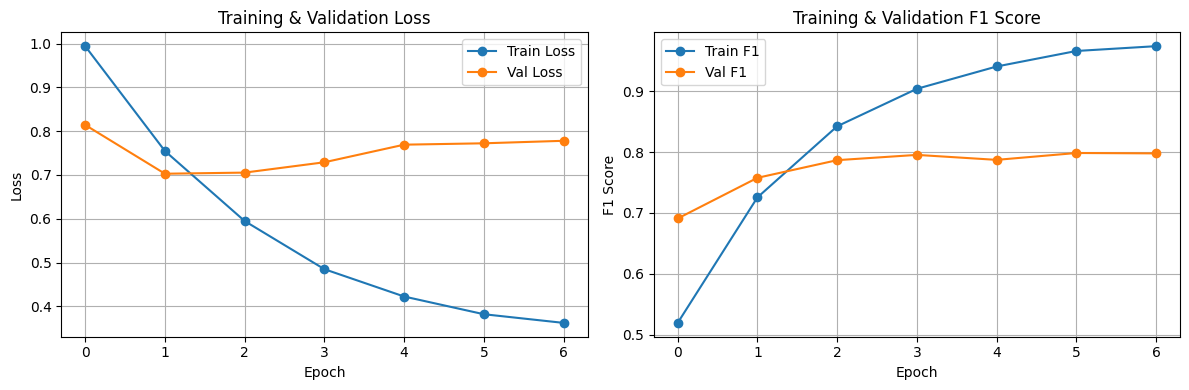

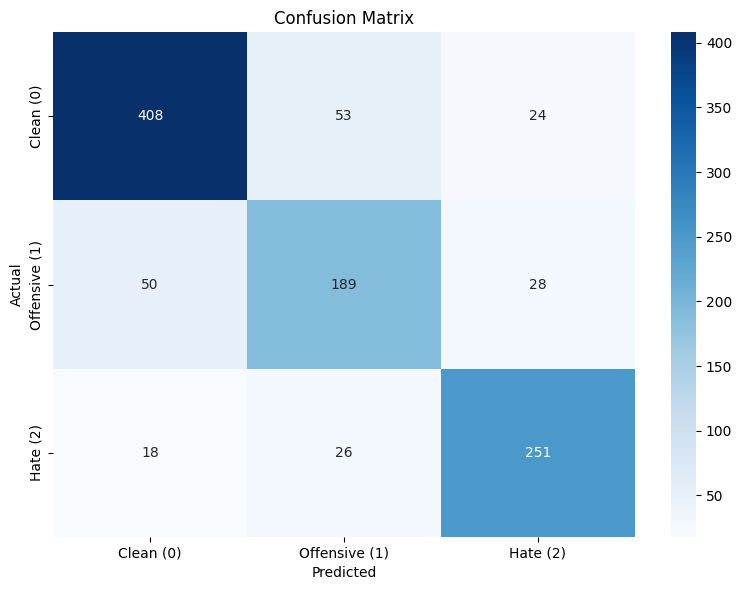


✅ Plots saved to: /content/drive/MyDrive/SafeSense-VI/output_v2


In [30]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10: Final Evaluation & Visualization
# ═══════════════════════════════════════════════════════════════════════════════

print("\n📊 FINAL EVALUATION")
print("="*80)

# Load best model
model = AutoModelForSequenceClassification.from_pretrained(Config.MODEL_SAVE_PATH)
model.to(Config.DEVICE)

# Final evaluation
val_loss, val_f1, val_acc, val_preds, val_labels = evaluate(
    model, val_loader, criterion, Config.DEVICE
)

# Classification Report
label_names = ['Clean (0)', 'Offensive (1)', 'Hate (2)']
print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(val_labels, val_preds, target_names=label_names))

# Confusion Matrix
print("\n📊 CONFUSION MATRIX:")
cm = confusion_matrix(val_labels, val_preds)
print(cm)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True)

# F1 Score
axes[1].plot(history['train_f1'], label='Train F1', marker='o')
axes[1].plot(history['val_f1'], label='Val F1', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Training & Validation F1 Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)
plt.savefig(f'{Config.OUTPUT_DIR}/training_history.png', dpi=150)
plt.show()

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{Config.OUTPUT_DIR}/confusion_matrix.png', dpi=150)
plt.show()

print(f"\n✅ Plots saved to: {Config.OUTPUT_DIR}")


In [44]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11: Inference Function
# ═══════════════════════════════════════════════════════════════════════════════

def predict(text, model, tokenizer, device):
    """Predict toxicity of a single text"""
    model.eval()

    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=Config.MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    label_names = {0: 'Clean', 1: 'Offensive', 2: 'Hate'}

    return {
        'prediction': pred,
        'label': label_names[pred],
        'probabilities': {
            'Clean': probs[0][0].item(),
            'Offensive': probs[0][1].item(),
            'Hate': probs[0][2].item()
        }
    }


# Test inference
print("\n🧪 TEST INFERENCE")
print("="*80)

test_texts = [
    "Tòa án tuyên án tử hình rồi mà",
    "Thằng này ngu vl",
    "chán thật",
]

for text in test_texts:
    result = predict(text, model, tokenizer, Config.DEVICE)
    print(f"\n📝 Text: {text}")
    print(f"   🏷️ Prediction: {result['label']} ({result['prediction']})")
    print(f"   📊 Probabilities: Clean={result['probabilities']['Clean']:.3f}, "
          f"Offensive={result['probabilities']['Offensive']:.3f}, "
          f"Hate={result['probabilities']['Hate']:.3f}")

print("\n" + "="*80)
print("🎉 TRAINING COMPLETE!")
print("="*80)



🧪 TEST INFERENCE

📝 Text: Tòa án tuyên án tử hình rồi mà
   🏷️ Prediction: Clean (0)
   📊 Probabilities: Clean=0.913, Offensive=0.042, Hate=0.045

📝 Text: Thằng này ngu vl
   🏷️ Prediction: Offensive (1)
   📊 Probabilities: Clean=0.017, Offensive=0.961, Hate=0.022

📝 Text: chán thật
   🏷️ Prediction: Clean (0)
   📊 Probabilities: Clean=0.862, Offensive=0.090, Hate=0.048

🎉 TRAINING COMPLETE!
